In [19]:
import cv2
import matplotlib.pyplot as plt
import os

In [20]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [21]:
cd /content/drive/MyDrive/'Colab Notebooks/human-activity-understanding/HW2'

/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2


In [22]:
image_directories = [
    "/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_gianos/141722079467",
    "/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_lucia/138422075916",
    "/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_david/141722075184"
]

print("Extracted image directories:")
for path in image_directories:
    print(path)

Extracted image directories:
/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_gianos/141722079467
/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_lucia/138422075916
/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_david/141722075184


## Collect and Select Files


In [23]:
CLASSES = ['person','table', 'leg','tool1', 'tool2']
print("Defined CLASSES list:", CLASSES)

Defined CLASSES list: ['person', 'table', 'leg', 'tool1', 'tool2']


## Update File Collection with Depth Images


In [25]:
import os
import random

# Assuming image_directories is already defined from the previous step
# image_directories = [
#     "/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_gianos/141722079467",
#     "/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_lucia/138422075916",
#     "/content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_david/141722075184"
# ]

all_image_label_depth_triplets_by_dir = [] # Updated list name

print("Collecting image, label, and depth file paths...")
for img_dir in image_directories:
    current_dir_triplets = []
    labels_dir = os.path.join(img_dir, 'labels')
    depth_dir = os.path.join(img_dir, 'depth') # New: depth directory

    if not os.path.exists(img_dir) or not os.path.isdir(img_dir):
        print(f"Warning: Image directory not found or is not a directory: {img_dir}")
        continue
    if not os.path.exists(labels_dir) or not os.path.isdir(labels_dir):
        print(f"Warning: Labels directory not found or is not a directory: {labels_dir}")
        continue
    if not os.path.exists(depth_dir) or not os.path.isdir(depth_dir): # New: check depth directory
        print(f"Warning: Depth directory not found or is not a directory: {depth_dir}")
        continue

    # Get all .jpg images
    image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg'))]

    # Get all .txt label files in the 'labels' subfolder
    label_files = [f for f in os.listdir(labels_dir) if f.lower().endswith('.txt')]

    # New: Get all .png depth files in the 'depth' subfolder
    depth_files = [f for f in os.listdir(depth_dir) if f.lower().endswith('.png')]

    # Create dictionaries for quick lookup of label and depth files
    label_map = {os.path.splitext(f)[0]: f for f in label_files}
    depth_map = {os.path.splitext(f)[0]: f for f in depth_files} # New: depth map

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        if base_name in label_map and base_name in depth_map: # New: check depth map as well
            full_image_path = os.path.join(img_dir, img_file)
            full_label_path = os.path.join(labels_dir, label_map[base_name])
            full_depth_path = os.path.join(depth_dir, depth_map[base_name]) # New: depth path
            current_dir_triplets.append((full_image_path, full_label_path, full_depth_path)) # Updated tuple

    if not current_dir_triplets:
        print(f"No matching image-label-depth triplets found in {img_dir}") # Updated message
    else:
        print(f"Found {len(current_dir_triplets)} triplets in {img_dir}") # Updated message
    all_image_label_depth_triplets_by_dir.append(current_dir_triplets) # Updated list name


selected_image_label_depth_triplets = [] # Updated list name for selected items
total_directories = len(all_image_label_depth_triplets_by_dir)

if total_directories > 0:
    # Determine how many samples to select from each directory
    target_total_samples = 200
    max_samples_per_dir = target_total_samples // total_directories
    # remaining_samples = target_total_samples % total_directories # Not strictly needed for this logic

    for i, dir_triplets in enumerate(all_image_label_depth_triplets_by_dir): # Updated list name
        num_available = len(dir_triplets)
        num_to_select = min(max_samples_per_dir, num_available)

        # Randomly select triplets from the current directory
        selected_from_dir = random.sample(dir_triplets, num_to_select)
        selected_image_label_depth_triplets.extend(selected_from_dir) # Updated list name

print(f"Total selected image-label-depth triplets: {len(selected_image_label_depth_triplets)}") # Updated message

Found 300 triplets in /content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_gianos/141722079467
Found 280 triplets in /content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_lucia/138422075916
Found 280 triplets in /content/drive/MyDrive/Colab Notebooks/human-activity-understanding/HW2/train_images_david/141722075184
Total selected image-label-depth triplets: 198


## Update File Copying for Depth Images



In [26]:
import shutil
import os

# Define the new directories
TRAIN_IMAGES_DIR = 'train_images'
TRAIN_LABELS_DIR = os.path.join(TRAIN_IMAGES_DIR, 'labels')
TRAIN_DEPTH_DIR = os.path.join(TRAIN_IMAGES_DIR, 'depth') # New: Define depth directory

# Create the directories if they don't exist
os.makedirs(TRAIN_IMAGES_DIR, exist_ok=True)
os.makedirs(TRAIN_LABELS_DIR, exist_ok=True)
os.makedirs(TRAIN_DEPTH_DIR, exist_ok=True) # New: Create depth directory

print(f"Created directory: {TRAIN_IMAGES_DIR}")
print(f"Created directory: {TRAIN_LABELS_DIR}")
print(f"Created directory: {TRAIN_DEPTH_DIR}") # New: Print confirmation for depth directory

# Copy the selected image, label, and depth files to the new directories
print("Copying selected image-label-depth triplets...")
for img_path, label_path, depth_path in selected_image_label_depth_triplets: # Updated to iterate over triplets
    # Copy image file
    shutil.copy(img_path, os.path.join(TRAIN_IMAGES_DIR, os.path.basename(img_path)))
    # Copy label file
    shutil.copy(label_path, os.path.join(TRAIN_LABELS_DIR, os.path.basename(label_path)))
    # New: Copy depth file
    shutil.copy(depth_path, os.path.join(TRAIN_DEPTH_DIR, os.path.basename(depth_path)))

print(f"Successfully copied {len(selected_image_label_depth_triplets)} image-label-depth triplets to '{TRAIN_IMAGES_DIR}', '{TRAIN_LABELS_DIR}' and '{TRAIN_DEPTH_DIR}'.")


Created directory: train_images
Created directory: train_images/labels
Created directory: train_images/depth
Copying selected image-label-depth triplets...
Successfully copied 198 image-label-depth triplets to 'train_images', 'train_images/labels' and 'train_images/depth'.


## Visualize Color and Depth Images with Annotations



Visualizing 3 random images and their depth maps...


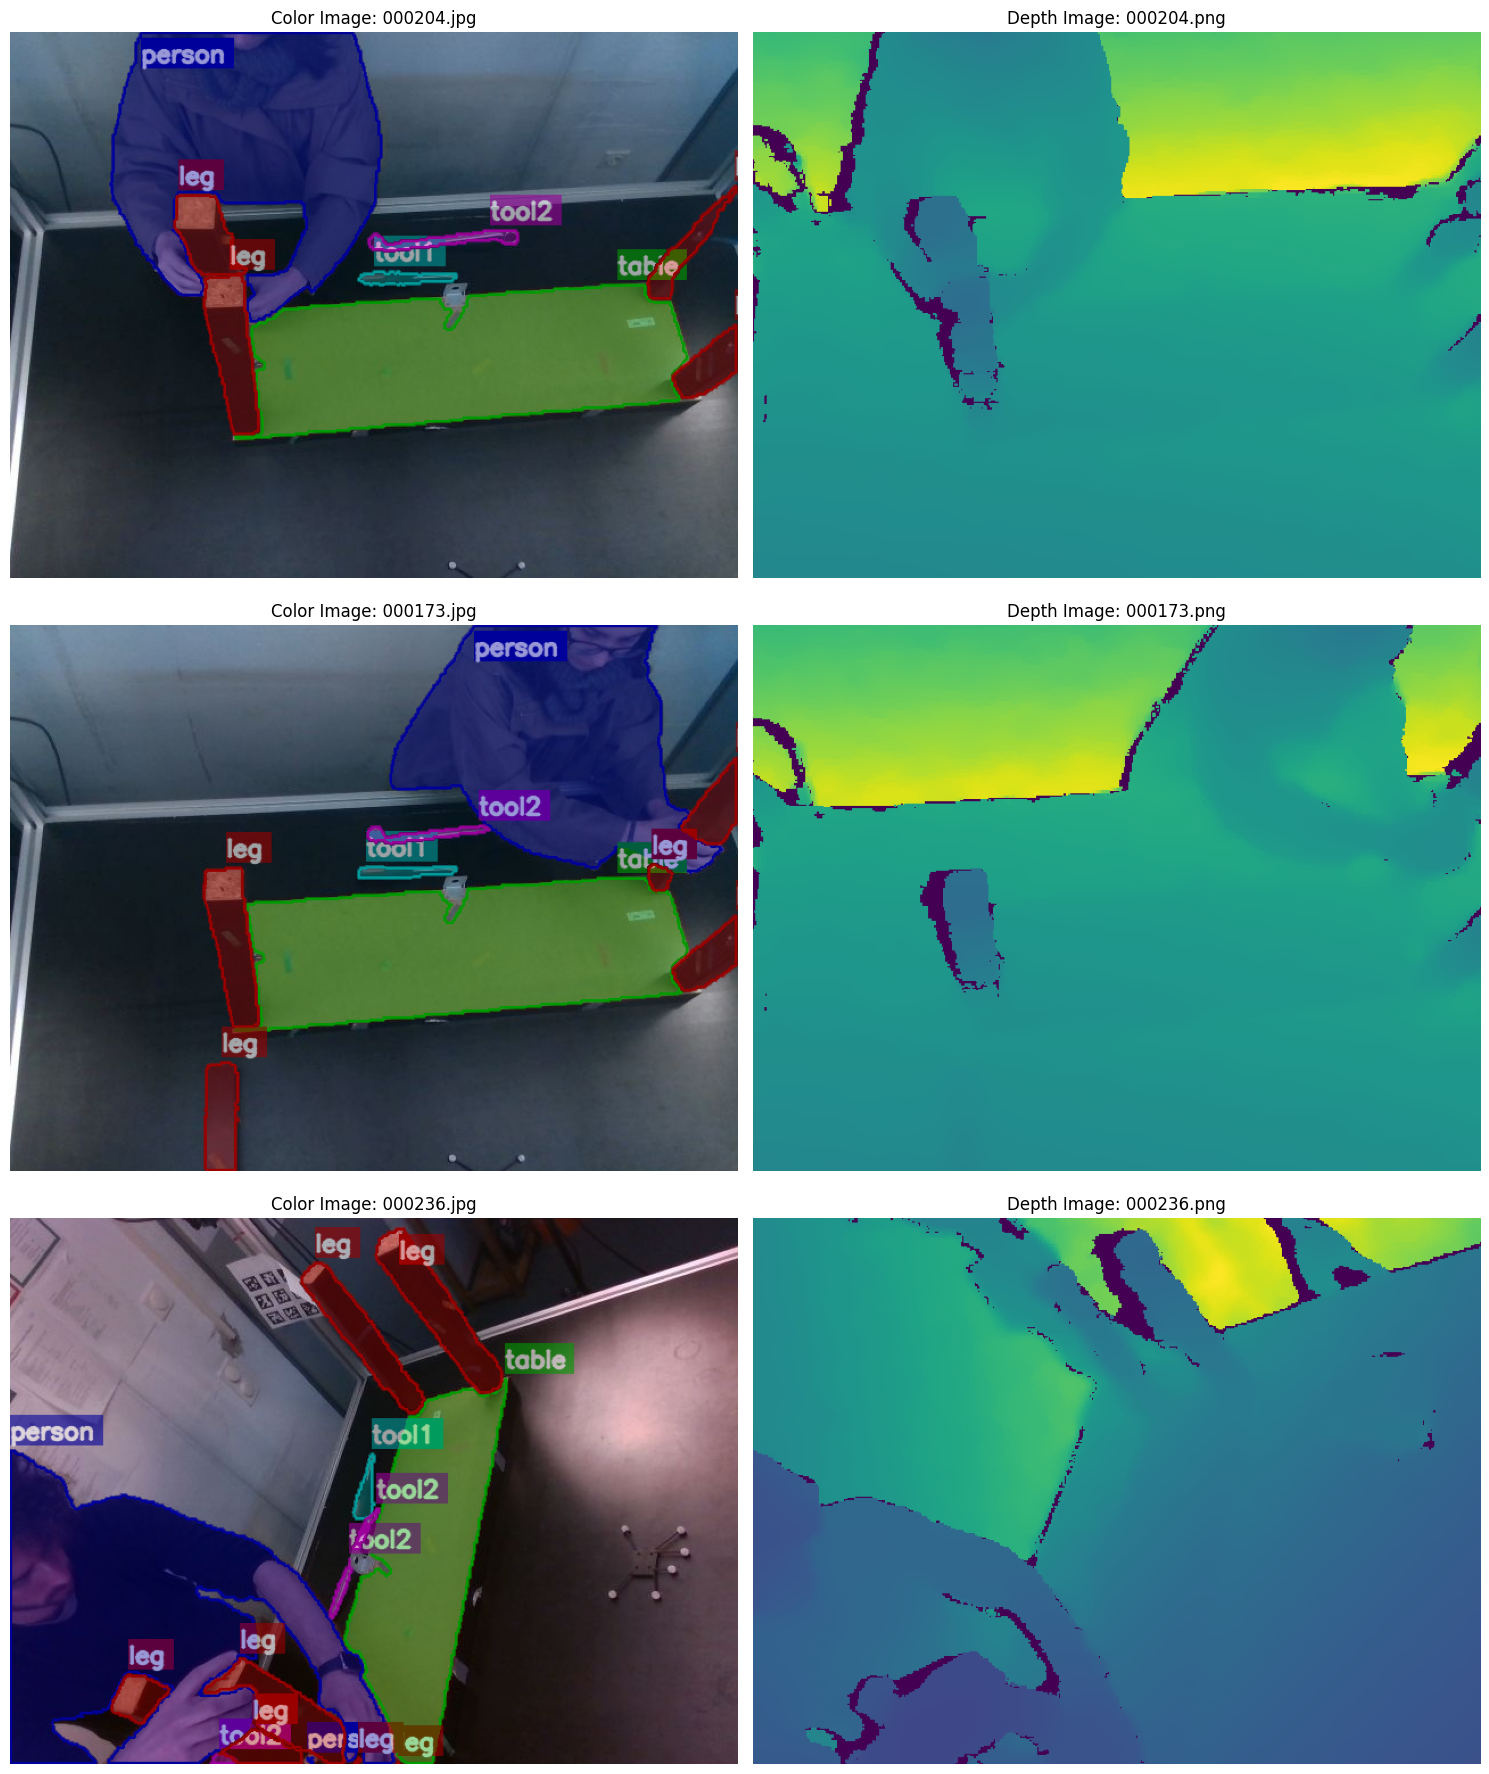

Finished visualizing 3 images with color annotations and depth maps.


In [27]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np # numpy is used in draw_bboxes_and_labels

# Re-define CLASSES as it was not in the current scope
CLASSES = ['person','table', 'leg','tool1', 'tool2']

def parse_yolo_label(label_path, img_width, img_height):
    """
    Parses a YOLO format segmentation label file and returns a list of masks.
    Each mask is returned as (class_id, polygon_points) where polygon_points is a list of (x, y) tuples in pixel coordinates.
    """
    masks = []
    if not os.path.exists(label_path):
        print(f"Warning: Label file not found: {label_path}")
        return masks

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3: # Must have at least class_id, x1, y1
                class_id = int(parts[0])
                polygon_normalized = list(map(float, parts[1:]))

                # Convert normalized coordinates to pixel coordinates
                polygon_points = []
                for i in range(0, len(polygon_normalized), 2):
                    x = int(polygon_normalized[i] * img_width)
                    y = int(polygon_normalized[i+1] * img_height)
                    polygon_points.append((x, y))
                masks.append((class_id, polygon_points))
    return masks

def draw_bboxes_and_labels(image, masks, classes):
    """
    Draws segmentation masks and class labels on an image with semi-transparent colors.
    """
    img_copy = image.copy()
    overlay = img_copy.copy()
    alpha = 0.4  # Transparency factor

    # Define a set of distinct colors for classes (BGR format for OpenCV)
    class_colors = [
        (0, 0, 155),    # Red for class 0 (person)
        (0, 155, 0),    # Green for class 1 (table)
        (155, 0, 0),    # Blue for class 2 (leg)
        (0, 155, 155),  # Yellow for class 3 (tool1)
        (155, 0, 155)   # Magenta for class 4 (tool2)
    ]

    for class_id, polygon_points in masks:
        if polygon_points:
            # Get color for the class
            color = class_colors[class_id % len(class_colors)] if class_id < len(class_colors) else (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) # Fallback random color

            # Reshape points for cv2.fillPoly and cv2.polylines
            pts = np.array(polygon_points, np.int32)
            pts = pts.reshape((-1, 1, 2))

            # Fill the polygon on the overlay with semi-transparency
            cv2.fillPoly(overlay, [pts], color)

            # Draw polygon outline
            cv2.polylines(img_copy, [pts], True, color, 2)

            # Put label
            label = classes[class_id] if class_id < len(classes) else f"Unknown Class {class_id}"
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.7
            font_thickness = 2
            text_size = cv2.getTextSize(label, font, font_scale, font_thickness)[0]

            # Place text near the first point of the polygon
            text_x = polygon_points[0][0]
            text_y = polygon_points[0][1] - 10 if polygon_points[0][1] - 10 > text_size[1] else polygon_points[0][1] + text_size[1] + 10

            # Draw background for text
            cv2.rectangle(img_copy, (text_x, text_y - text_size[1] - 5),
                          (text_x + text_size[0] + 5, text_y + 5), color, -1)
            cv2.putText(img_copy, label, (text_x, text_y), font, font_scale, (255, 255, 255), font_thickness, cv2.LINE_AA)

    # Combine the original image with the overlay using the transparency factor
    img_with_masks = cv2.addWeighted(overlay, alpha, img_copy, 1 - alpha, 0)
    return img_with_masks

# Get a list of all image files in the new training directory
train_image_files = [f for f in os.listdir(TRAIN_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg'))]

# Randomly select 3 images to visualize
num_images_to_visualize = min(3, len(train_image_files)) # Ensure we don't try to visualize more than available
selected_images_for_viz = random.sample(train_image_files, num_images_to_visualize)

print(f"Visualizing {num_images_to_visualize} random images and their depth maps...")

plt.figure(figsize=(15, 6 * num_images_to_visualize))

for i, img_filename in enumerate(selected_images_for_viz):
    img_path = os.path.join(TRAIN_IMAGES_DIR, img_filename)
    label_filename = os.path.splitext(img_filename)[0] + '.txt'
    label_path = os.path.join(TRAIN_LABELS_DIR, label_filename)
    depth_filename = os.path.splitext(img_filename)[0] + '.png'
    depth_path = os.path.join(TRAIN_DEPTH_DIR, depth_filename)

    # Read the color image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image: {img_path}")
        continue

    # OpenCV reads images as BGR, convert to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read the depth image
    depth_image = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
    if depth_image is None:
        print(f"Warning: Could not read depth image: {depth_path}")
        continue

    img_height, img_width, _ = img_rgb.shape

    # Parse YOLO labels
    bboxes = parse_yolo_label(label_path, img_width, img_height)

    # Draw bounding boxes and labels on the color image
    img_with_boxes = draw_bboxes_and_labels(img_rgb, bboxes, CLASSES)

    # Normalize depth image for visualization
    # Scale to 0-255 for 8-bit display
    normalized_depth_image = cv2.normalize(depth_image, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # Display the annotated color image
    plt.subplot(num_images_to_visualize, 2, i * 2 + 1) # First column for color image
    plt.imshow(img_with_boxes)
    plt.title(f"Color Image: {img_filename}")
    plt.axis('off')

    # Display the normalized depth image
    plt.subplot(num_images_to_visualize, 2, i * 2 + 2) # Second column for depth image
    plt.imshow(normalized_depth_image, cmap='viridis')
    plt.title(f"Depth Image: {depth_filename}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Finished visualizing {num_images_to_visualize} images with color annotations and depth maps.")

## Prepare Dataset for Ultralytics

Organize custom dataset into the YOLO format required by `ultralytics`, including creating a `data.yaml` configuration file that specifies paths to your training/validation images and labels, and defines class names.

In [30]:
import os
import shutil
import random

# 2. Define variables for the original training images directory, labels directory, and class names
TRAIN_IMAGES_DIR = 'train_images'
TRAIN_LABELS_DIR = os.path.join(TRAIN_IMAGES_DIR, 'labels')
TRAIN_DEPTH_DIR = os.path.join(TRAIN_IMAGES_DIR, 'depth') # Added depth directory
CLASSES = ['person', 'table', 'leg', 'tool1', 'tool2']

# 3. Define a new base directory for the YOLO dataset
dataset_yolo_path = 'dataset_yolo'

# 4. Create the necessary subdirectories for the YOLO format
os.makedirs(os.path.join(dataset_yolo_path, 'images', 'train'), exist_ok=True)
os.makedirs(os.path.join(dataset_yolo_path, 'images', 'val'), exist_ok=True)
os.makedirs(os.path.join(dataset_yolo_path, 'labels', 'train'), exist_ok=True)
os.makedirs(os.path.join(dataset_yolo_path, 'labels', 'val'), exist_ok=True)
os.makedirs(os.path.join(dataset_yolo_path, 'depth', 'train'), exist_ok=True) # Create depth train directory
os.makedirs(os.path.join(dataset_yolo_path, 'depth', 'val'), exist_ok=True)  # Create depth val directory

print("YOLO dataset directories created.")

# 5. Get a list of all image files in the training directory
image_files = [f for f in os.listdir(TRAIN_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 6. Create a list of tuples (image_path, label_path, depth_path) and filter out images without corresponding labels or depth
data_triplets = [] # Changed to triplets
for img_filename in image_files:
    base_name = os.path.splitext(img_filename)[0]
    img_path = os.path.join(TRAIN_IMAGES_DIR, img_filename)
    label_path = os.path.join(TRAIN_LABELS_DIR, base_name + '.txt')
    depth_path = os.path.join(TRAIN_DEPTH_DIR, base_name + '.png') # Get depth path

    if os.path.exists(label_path) and os.path.exists(depth_path):
        data_triplets.append((img_path, label_path, depth_path)) # Append triplet
    else:
        print(f"Warning: Missing label or depth file for {img_filename}. Skipping.")

print(f"Found {len(data_triplets)} image-label-depth triplets.")

# 7. Split into training and validation sets (80% train, 20% val)
random.shuffle(data_triplets) # Shuffle triplets
train_split_idx = int(0.8 * len(data_triplets))
train_set = data_triplets[:train_split_idx]
val_set = data_triplets[train_split_idx:]

print(f"Training set size: {len(train_set)} images")
print(f"Validation set size: {len(val_set)} images")

# 8. Iterate through the training set and copy files
for img_path, label_path, depth_path in train_set: # Iterate over triplets
    img_filename = os.path.basename(img_path)
    label_filename = os.path.basename(label_path)
    depth_filename = os.path.basename(depth_path) # Get depth filename
    shutil.copy(img_path, os.path.join(dataset_yolo_path, 'images', 'train', img_filename))
    shutil.copy(label_path, os.path.join(dataset_yolo_path, 'labels', 'train', label_filename))
    shutil.copy(depth_path, os.path.join(dataset_yolo_path, 'depth', 'train', depth_filename)) # Copy depth file
print("Training images, labels, and depth copied.")

# 9. Iterate through the validation set and copy files
for img_path, label_path, depth_path in val_set: # Iterate over triplets
    img_filename = os.path.basename(img_path)
    label_filename = os.path.basename(label_path)
    depth_filename = os.path.basename(depth_path) # Get depth filename
    shutil.copy(img_path, os.path.join(dataset_yolo_path, 'images', 'val', img_filename))
    shutil.copy(label_path, os.path.join(dataset_yolo_path, 'labels', 'val', label_filename))
    shutil.copy(depth_path, os.path.join(dataset_yolo_path, 'depth', 'val', depth_filename)) # Copy depth file
print("Validation images, labels, and depth copied.")

# 10. and 11. Create a data.yaml file
data_yaml_content = f"""
path: {dataset_yolo_path}
train: images/train
val: images/val

nc: {len(CLASSES)}
names: {CLASSES}
"""

with open('data.yaml', 'w') as f:
    f.write(data_yaml_content)

print("data.yaml created.")
print("Dataset organized and data.yaml generated successfully.")

YOLO dataset directories created.
Found 157 image-label-depth triplets.
Training set size: 125 images
Validation set size: 32 images
Training images, labels, and depth copied.
Validation images, labels, and depth copied.
data.yaml created.
Dataset organized and data.yaml generated successfully.
